# Praktikum Machine Learning: Bab 3
## Data Preparation Lanjutan: Missing Values, Outlier, dan Imbalanced Data

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini gw jalanin di Google Colab / Jupyter Notebook. dataset yang gw pake: **Telco Customer Churn** (7043 pelanggan, dari Kaggle), filenya `data/telco-customer-churn.csv` (nama asli di Kaggle: `WA_Fn-UseC_-Telco-Customer-Churn.csv`). Kalau dijalanin di Colab, sesuaikan path-nya di cell `DATA_PATH` (misalnya `/content/WA_Fn-UseC_-Telco-Customer-Churn.csv`).

Praktikum Bab 3 ini ngikutin struktur modul bagian 3.9-3.10, tapi semua langkah gw terapin ke **data real** Telco Customer Churn. Kolom `TotalCharges` emang punya missing value alami (kesimpan sebagai string kosong), ada beberapa baris yang tergolong outlier, dan kelas `Churn` nggak seimbang (churn cuma sekitar 26%).


## Ringkasan Konsep

**Missing values.** Data yang hilang itu ada macem-macem tipenya: *MCAR* (hilang murni acak), *MAR* (hilangnya berkaitan sama variabel lain), dan *MNAR* (hilangnya berkaitan sama nilainya sendiri). Strategi imputasi yang umum:
- **Mean/median imputation**, cepet, tapi variansi datanya jadi ketekan;
- **KNN Imputer**, ngisi dari rata-rata *k* tetangga terdekat, jadi lebih merhatiin pola lokal;
- imputasi berbasis model (misalnya regresi) buat kasus yang lebih ribet.

**Deteksi outlier.** Outlier itu titik data yang nyimpang jauh dari pola mayoritas, bisa ngaco-in model. Salah satu metode yang populer: **Isolation Forest**. Cara kerjanya, dia "mengisolasi" tiap titik pakai partisi acak, dan titik yang cepet keisolasi (sedikit partisi) dianggap anomali. Parameter `contamination` itu tebakan kita soal proporsi outlier di data.

**Imbalanced data.** Kalau satu kelas jauh lebih dikit (misalnya churn 26% vs nggak churn 74%), model jadi males: cukup nebak kelas mayoritas terus aja udah dapet akurasi tinggi. Teknik penanganannya:
- **SMOTE** (oversampling sintetis buat kelas minoritas), bikin sampel baru dari interpolasi tetangga kelas minoritas, dan cuma diaplikasiin ke **data latih**;
- **Random undersampling**, buang sampel kelas mayoritas secara acak;
- **`class_weight='balanced'`**, ngasih bobot loss yang lebih gede ke kelas minoritas.

**Kenapa akurasi menipu?** Di data imbalance, akurasi bisa keliatan tinggi padahal modelnya nyaris nggak ngenalin kelas minoritas. Metrik yang lebih jujur itu **precision, recall, dan F1-score** buat kelas minoritas (detailnya dibahas di Bab 7).


## 3.9 Implementasi Python

Di praktikum ini gw pake **data real Telco Customer Churn** (Modul Bab 3, bagian 3.9). Alurnya: muat data, cek missing, imputasi KNN + buang outlier (Isolation Forest), one-hot encoding, split stratifikasi, latih *baseline* vs SMOTE, terus evaluasi akurasi & F1.


### Praktikum 3.1 - Persiapan Library (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.1 dari Modul Machine Learning Bab 3. Pertama gw import semua library yang dibutuhin dulu: `KNNImputer` buat imputasi, `IsolationForest` buat deteksi outlier, `SMOTE` dari `imblearn` buat oversampling, plus `LogisticRegression`, `train_test_split`, dan metrik evaluasi dari scikit-learn.


In [1]:
%matplotlib inline
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")  # biar output bersih, warning-nya disembunyiin
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan outputnya:** cell-nya jalan tanpa error, artinya `pandas`, `numpy`, `matplotlib`, `scikit-learn`, dan `imbalanced-learn` tersedia di environment ini.


### Praktikum 3.2 - Import Dataset (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.2 dari Modul Machine Learning Bab 3. Gw baca CSV churn, terus liat kondisi datanya: dimensi, jumlah *missing value* per kolom, dan distribusi kelas `Churn`. Nah, `TotalCharges` kebaca sebagai string karena isinya ada yang kosong (`" "`). Jadi gw konversi ke numerik pakai `errors='coerce'` biar nilai kosongnya berubah jadi `NaN` (ini missing value alaminya).


In [2]:
# Dataset dibaca dari file CSV lokal - bisa dipakai offline
DATA_PATH = "data/telco-customer-churn.csv"

df = pd.read_csv(DATA_PATH)
print("Dimensi dataset:", df.shape)
print()

# TotalCharges tersimpan sebagai string -> konversi ke numerik; " " menjadi NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing value per kolom (hanya kolom yang bermasalah):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Distribusi kelas Churn:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(4))

Dimensi dataset: (7043, 21)

Missing value per kolom (hanya kolom yang bermasalah):
TotalCharges    11
dtype: int64

Distribusi kelas Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


**Penjelasan outputnya:**
1. Dataset-nya berukuran **(7043, 21)**: 7.043 pelanggan dan 21 kolom.
2. Hasil `isnull().sum()` nunjukin cuma **`TotalCharges` yang punya missing value: 11 baris**. Persis kayak catatan dataset-nya.
3. Distribusi kelas `Churn`: **5174 pelanggan nggak churn (73,46%)** vs **1869 churn (26,54%)**. Datanya jelas *imbalance*, tapi nggak ekstrem (beda sama contoh sintetis di modul yang 95:5).
4. Kolom lain nggak ada yang missing, jadi langkah imputasi cukup difokusin ke kolom numerik.


### Praktikum 3.3 - Preprocessing: Imputasi KNN & Deteksi Outlier (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.3 dari Modul Machine Learning Bab 3. Kolom numerik (`tenure`, `MonthlyCharges`, `TotalCharges`) gw imputasi pakai `KNNImputer(n_neighbors=5)`. Terus `IsolationForest(contamination=0.02)` gw pake buat nandain outlier, dan baris yang kedeteksi **dibuang**. Setelah bersih, kolom kategorikal di-*one-hot encoding* (kolom `customerID` dibuang, soalnya cuma ID, bukan fitur prediktif) dan target `Churn` dipetain Yes ke 1, No ke 0.


In [3]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df.columns if c not in num_cols + ["customerID", "Churn"]]

def build_data(contamination=0.02, imputer="knn"):
    d = df.copy()
    # 1) Imputasi kolom numerik
    if imputer == "knn":
        imp = KNNImputer(n_neighbors=5)
    else:
        imp = SimpleImputer(strategy="median")
    d[num_cols] = imp.fit_transform(d[num_cols])
    # 2) Deteksi outlier pada fitur numerik
    iso = IsolationForest(contamination=contamination, random_state=42)
    is_outlier = iso.fit_predict(d[num_cols]) == -1
    n_out = int(is_outlier.sum())
    d = d[~is_outlier]
    # 3) One-hot encoding kolom kategorikal, buang customerID
    d = pd.get_dummies(d, columns=cat_cols, drop_first=True)
    X = d.drop(columns=["customerID", "Churn"])
    y = (d["Churn"] == "Yes").astype(int)
    return X, y, n_out

X, y, n_outliers = build_data()
print(f"Jumlah outlier terdeteksi (contamination=0.02): {n_outliers} baris")
print("Dimensi X setelah cleaning + one-hot encoding:", X.shape)
print("Missing value tersisa:", int(X.isnull().sum().sum()))
print("Jumlah fitur hasil one-hot encoding:", X.shape[1])

Jumlah outlier terdeteksi (contamination=0.02): 141 baris
Dimensi X setelah cleaning + one-hot encoding: (6902, 30)
Missing value tersisa: 0
Jumlah fitur hasil one-hot encoding: 30


**Penjelasan outputnya:**
1. `IsolationForest(contamination=0.02)` nandain **141 baris (sekitar 2% dari 7.043)** sebagai outlier. Sesuai sama `contamination` yang gw set.
2. Dimensi X jadi **(6902, 30)**: 141 baris outlier dibuang, dan 15 kolom kategorikal berubah jadi 27 kolom biner hasil one-hot (drop_first=True).
3. Missing value yang tersisa **0**. Imputasi KNN berhasil nutup 11 lubang di `TotalCharges`.
4. Imputasi gw lakuin *sebelum* outlier dibuang biar model KNN tetap belajar dari pola yang lengkap. One-hot-nya paling *terakhir* karena IsolationForest cuma jalan bagus di fitur numerik.


### Praktikum 3.4 - Training Model dengan dan tanpa SMOTE (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.4 dari Modul Machine Learning Bab 3. Data dibagi **stratifikasi** (80% latih / 20% uji, `random_state=42`) biar proporsi churn di kedua set sama. Model *baseline* = `LogisticRegression(max_iter=1000)` tanpa perlakuan imbalance. Model kedua pake **SMOTE(random_state=42) yang cuma diaplikasiin ke data latih**. Data uji dibiarin apa adanya biar evaluasinya tetap jujur.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data latih: {len(X_train)} | Data uji: {len(X_test)}")

print("\nDistribusi kelas train SEBELUM SMOTE:", np.bincount(y_train))

# SMOTE hanya pada train set!
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Distribusi kelas train SESUDAH SMOTE:", np.bincount(y_train_sm))

# Baseline
model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train, y_train)

# Dengan SMOTE
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_sm, y_train_sm)
print("\nKedua model selesai dilatih.")

Data latih: 5521 | Data uji: 1381

Distribusi kelas train SEBELUM SMOTE: [4034 1487]
Distribusi kelas train SESUDAH SMOTE: [4034 4034]



Kedua model selesai dilatih.


**Penjelasan outputnya:**
1. Split-nya ngasilin **5.521 data latih** dan **1.381 data uji**.
2. Distribusi kelas latih sebelum SMOTE: **[4034 nggak churn, 1487 churn]**. Imbalance-nya kejaga kayak data asli berkat `stratify`.
3. Sesudah SMOTE: **[4034, 4034]**. Kelas minoritas disintesis sampe seimbang sempurna. `fit_resample` cuma dipanggil di `X_train`, jadi data uji (1.381 baris) nggak kekontaminasi sampel sintetis.
4. Kedua `LogisticRegression` kelatih tanpa warning konvergensi (`max_iter=1000` cukup).


### Praktikum 3.5 - Evaluasi: Akurasi & F1-Score (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.5 dari Modul Machine Learning Bab 3. Sesuai modul, gw bandingin *baseline* sama model SMOTE dalam satu loop: cetak **akurasi** dan **F1-score** masing-masing, plus `classification_report` biar keliatan per kelasnya (khususnya kelas Churn).


In [5]:
for nama, model in [("Baseline (tanpa SMOTE)", model_base),
                       ("Dengan SMOTE", model_smote)]:
    y_pred = model.predict(X_test)
    akurasi = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{nama}: akurasi = {akurasi:.4f} ({akurasi:.2%}) | F1-score = {f1:.4f}")

print("\n=== Classification report: Baseline ===")
print(classification_report(y_test, model_base.predict(X_test),
                            digits=3, target_names=["Tidak Churn", "Churn"]))
print("=== Classification report: Dengan SMOTE ===")
print(classification_report(y_test, model_smote.predict(X_test),
                            digits=3, target_names=["Tidak Churn", "Churn"]))

Baseline (tanpa SMOTE): akurasi = 0.8081 (80.81%) | F1-score = 0.6003
Dengan SMOTE: akurasi = 0.7762 (77.62%) | F1-score = 0.5961

=== Classification report: Baseline ===
              precision    recall  f1-score   support

 Tidak Churn      0.841     0.909     0.874      1009
       Churn      0.684     0.535     0.600       372

    accuracy                          0.808      1381
   macro avg      0.763     0.722     0.737      1381
weighted avg      0.799     0.808     0.800      1381

=== Classification report: Dengan SMOTE ===
              precision    recall  f1-score   support

 Tidak Churn      0.854     0.836     0.845      1009
       Churn      0.580     0.613     0.596       372

    accuracy                          0.776      1381
   macro avg      0.717     0.725     0.721      1381
weighted avg      0.780     0.776     0.778      1381



**Penjelasan outputnya:**
1. **Baseline: akurasi 80,81%, F1 0,6003.** Sekilas bagus, tapi liat per kelasnya: *recall* kelas Churn cuma **0,535**. Artinya dari 372 pelanggan yang beneran churn, model cuma nangkep sekitar 199 orang. Sisanya (hampir separuh!) lolos tanpa kedeteksi.
2. **Pakai SMOTE: akurasi 77,62%, F1 0,5961.** Akurasinya *turun* 3,2 poin, tapi **recall kelas Churn naik ke 0,613**. Model nangkep sekitar 228 pelanggan churn (29 orang lebih banyak). Harganya: presisi kelas Churn turun dari 0,684 ke 0,580 karena model jadi "lebih berani" nebak churn.
3. F1 kedua model hampir sama (sekitar 0,60). Di dataset ini SMOTE nggak bikin F1 melonjak, tapi **ngegeser trade-off dari "aman nebak mayoritas" ke "lebih banyak nangkep churn"**. Buat bisnis retensi, nangkep 29 pelanggan churn tambahan jauh lebih berharga daripada 3 poin akurasi semu.
4. Ini bukti nyatanya pesan modul: **akurasi aja menipu**. Baseline keliatan menang 80,8% vs 77,6%, padahal dia gagal di kelas yang justru pengen diprediksi.


### Praktikum 3.6 - Visualisasi: Distribusi Kelas Train Sebelum vs Sesudah SMOTE (Modul Bab 3, bagian 3.9)

Bagian ini gw ngerjain Praktikum 3.6 dari Modul Machine Learning Bab 3. Bar chart berdampingan buat liat efek SMOTE secara visual: batang kelas Churn yang tadinya pendek jadi setinggi kelas mayoritas.


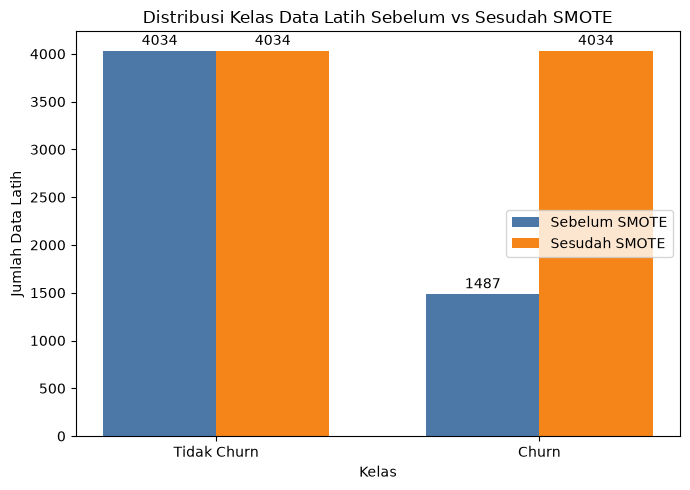

In [6]:
labels = ["Tidak Churn", "Churn"]
sebelum = np.bincount(y_train)
sesudah = np.bincount(y_train_sm)

x = np.arange(len(labels))
lebar = 0.35
plt.figure(figsize=(7, 5))
b1 = plt.bar(x - lebar/2, sebelum, lebar, label="Sebelum SMOTE", color="#4C78A8")
b2 = plt.bar(x + lebar/2, sesudah, lebar, label="Sesudah SMOTE", color="#F58518")
plt.xticks(x, labels)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data Latih")
plt.title("Distribusi Kelas Data Latih Sebelum vs Sesudah SMOTE")
plt.legend()
for b in list(b1) + list(b2):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 60,
             f"{int(b.get_height())}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
1. Batang biru (sebelum SMOTE): kelas "Tidak Churn" setinggi **4.034**, sedangkan "Churn" cuma **1.487**. Keliatan jelas imbalance-nya, sekitar 73:27.
2. Batang oranye (sesudah SMOTE): kedua batangnya **sama tinggi (4.034)**. SMOTE nambahin 4.034 - 1.487 = **2.547 sampel sintetis** kelas churn hasil interpolasi antar-tetangga kelas minoritas.
3. Label angka di atas tiap batang bikin nilai pastinya gampang dibaca.


### 3.9.1 Interpretasi (Modul Bab 3)

Hasil praktikum ini ngebuktiin (sekaligus ngasih nuansa ke) klaim modul:
1. **Akurasi bisa menipu.** Baseline unggul akurasi (80,8% vs 77,6%) tapi recall churn-nya cuma 53,5%. Model yang "curang nebak kelas mayoritas" emang ada di sini, walau nggak separah contoh sintetis 95:5 di modul.
2. **SMOTE ngubah trade-off, bukan sekadar naikin F1.** Di data ini F1-nya nyaris identik (sekitar 0,60), tapi recall churn naik 53,5% jadi 61,3% dengan ngorbanin presisi. Buat bisnis telekomunikasi, *false negative* (pelanggan churn yang nggak kedeteksi) lebih mahal daripada *false positive*, jadi pergeseran ini justru yang dibutuhin.
3. **Pipeline yang bener:** imputasi, buang outlier, one-hot encoding, split stratifikasi, SMOTE **cuma** di train set, terus evaluasi di test set yang murni. Kalau urutannya dibalik (misalnya SMOTE sebelum split) bakal ngebocorin info sintetis ke data uji.
4. Pemilihan metrik yang tepat buat data imbalance (precision/recall/F1, ROC-AUC, PR-AUC) dibahas tuntas di **Bab 7**.


## Eksperimen (Coba-Coba)

Bagian ini isinya percobaan mandiri: gw ubah-ubah parameter terus ngamatin apa yang kejadian ke jumlah outlier dan kualitas model (diukur pakai F1-score kelas Churn).


### Eksperimen 1 - Pengaruh `contamination` pada IsolationForest

Parameter `contamination` itu tebakan kita soal proporsi outlier. Gw coba 0,005 / 0,02 / 0,05 / 0,10, terus latih baseline LogisticRegression di tiap hasil cleaning dan bandingin F1-nya.


In [7]:
print(f"{'contamination':>13} | {'outlier dibuang':>14} | {'F1 baseline':>11}")
print("-" * 46)
for c in [0.005, 0.02, 0.05, 0.10]:
    Xe_, ye_, n_o = build_data(contamination=c)
    Xtr, Xte, ytr, yte = train_test_split(Xe_, ye_, test_size=0.2,
                                         random_state=42, stratify=ye_)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr, ytr)
    f1 = f1_score(yte, m.predict(Xte))
    print(f"{c:>13} | {n_o:>14} | {f1:>11.4f}")

contamination | outlier dibuang | F1 baseline
----------------------------------------------


        0.005 |             36 |      0.6114


         0.02 |            141 |      0.6003


         0.05 |            353 |      0.6086


          0.1 |            705 |      0.6228


**Penjelasan output & interpretasi:**
1. Jumlah outlier yang dibuang naik proporsional: **sekitar 36 (0,5%) jadi 141 (2%) jadi 353 (5%) jadi 705 (10%)**.
2. F1 baseline gerak di kisaran sempit: **0,6114 ke 0,6003 ke 0,6086 ke 0,6228**. Nggak ada pola monoton yang kuat. Artinya titik-titik yang ditandain IsolationForest di fitur numerik ini sebagian besar *bukan* noise yang ngerusak model. Buang terlalu agresif (10%) malah ngapus 705 baris data valid tanpa bener-bener ngebagusin F1.
3. Pelajarannya: `contamination` bukan "makin gede makin bersih". Nilai default 2% udah wajar buat dataset ini. Naikin tanpa validasi cuma buang-buang data.


### Eksperimen 2 - KNNImputer vs SimpleImputer (median)

Beneran nggak sih imputasi berbasis tetangga lebih bagus daripada sekadar ngisi median? Gw bandingin F1 baseline LogisticRegression buat keduanya (missing-nya cuma 11 baris, jadi ekspektasinya bedanya kecil).


In [8]:
print(f"{'strategi imputasi':>22} | {'akurasi':>8} | {'F1':>7}")
print("-" * 44)
for strat in ["knn", "median"]:
    Xe_, ye_, _ = build_data(imputer=strat)
    Xtr, Xte, ytr, yte = train_test_split(Xe_, ye_, test_size=0.2,
                                         random_state=42, stratify=ye_)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    print(f"{strat:>22} | {accuracy_score(yte, yp):>8.4f} | {f1_score(yte, yp):>7.4f}")

     strategi imputasi |  akurasi |      F1
--------------------------------------------


                   knn |   0.8081 |  0.6003


                median |   0.8016 |  0.6040


**Penjelasan output & interpretasi:**
1. KNN Imputer: akurasi **0,8081**, F1 **0,6003**. Median: akurasi **0,8016**, F1 **0,6040**.
2. Bedanya **kecil banget** (F1 selisih 0,004). Wajar, soalnya cuma 11 dari 7.043 baris (0,16%) yang diimputasi. Strategi imputasi nyaris nggak ngaruh ke model akhir.
3. Pelajarannya: KNN Imputer unggul secara teori (struktur lokalnya kejaga), tapi kalau missing-nya dikit, imputasi sederhana pun cukup. KNN Imputer baru bener-bener berarti pas missing-nya banyak atau berpola (MAR).


### Eksperimen 3 - SMOTE dengan `k_neighbors` 5 vs 3

SMOTE bikin sampel sintetis dari interpolasi `k_neighbors` tetangga terdekat kelas minoritas. Kira-kira k yang lebih kecil (sampelnya lebih "lokal") ngubah hasil nggak?


In [9]:
print(f"{'k_neighbors':>11} | {'akurasi':>8} | {'F1':>7}")
print("-" * 33)
for k in [5, 3]:
    sm = SMOTE(random_state=42, k_neighbors=k)
    Xtr_s, ytr_s = sm.fit_resample(X_train, y_train)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr_s, ytr_s)
    yp = m.predict(X_test)
    print(f"{k:>11} | {accuracy_score(y_test, yp):>8.4f} | "
          f"{f1_score(y_test, yp):>7.4f}")

k_neighbors |  akurasi |      F1
---------------------------------


          5 |   0.7762 |  0.5961


          3 |   0.7690 |  0.5905


**Penjelasan output & interpretasi:**
1. k=5: akurasi **0,7762**, F1 **0,5961**. k=3: akurasi **0,7690**, F1 **0,5905**.
2. k=3 sedikit lebih jelek di kedua metrik. Dengan k lebih kecil, sampel sintetis dibikin dari tetangga yang deket banget, jadi variasinya kurang dan model sedikit lebih overfit ke pola lokal kelas minoritas.
3. Pelajarannya: default `k_neighbors=5` udah pilihan yang aman. Nurunin k tanpa alasan cuma nambah noise sintetis. (Catatan: `X_train`/`y_train` di sini dipake ulang dari Praktikum 3.4. Konsisten karena cell-nya dijalanin berurutan.)


## Studi Kasus - Data Churn Telekomunikasi

**Masalah.** Sebuah perusahaan telekomunikasi pengen nebak pelanggan yang bakal berhenti langganan (*churn*) biar bisa dikasih penawaran retensi. Data historis 7.043 pelanggan ternyata "kotor": kolom `TotalCharges` punya 11 nilai kosong (kesimpan sebagai string `" "`), sekitar 2% baris nyimpang jauh dari pola umum (potensi outlier/entri salah), dan cuma **26,5%** pelanggan yang churn. Datanya nggak seimbang.

**Solusi yang diterapin.**
1. *Missing values*: konversi `TotalCharges` ke numerik (`errors='coerce'`), terus imputasi **KNN (k=5)** di kolom numerik.
2. *Outlier*: **IsolationForest** (`contamination=0.02`) buang 141 baris anomali.
3. *Imbalanced data*: **SMOTE** cuma di data latih, jadi kelas churn naik dari 1.487 jadi 4.034 sampel.
4. Model `LogisticRegression` dievaluasi pakai akurasi **dan** F1-score/precision/recall, bukan akurasi doang.

**Hasil.** Baseline keliatan bagus (akurasi 80,8%) tapi recall churn-nya cuma 53,5%. Sesudah SMOTE, recall churn naik ke **61,3%** (+29 pelanggan churn ketangkep dari 372 kasus uji) dengan F1 yang relatif stabil (sekitar 0,60). Kesimpulannya: pipeline data preparation bikin model lebih berguna buat tujuan bisnis (nangkep churn), sekalipun angka akurasinya turun. Bukti kalo metrik harus selaras sama tujuan, bukan sekadar keliatan tinggi.


## 3.10 Latihan Praktikum (Modul Bab 3)

### Latihan 1 - Perbandingan Strategi Imputasi (Modul Bab 3, bagian 3.10)

**Soal (modul 3.10):** bandingin *mean imputation* vs *KNN Imputer* terhadap F1-score Logistic Regression.

**Jawaban:** gw ulangin pipeline pakai `SimpleImputer(strategy="mean")` dan `KNNImputer(n_neighbors=5)`, terus latih baseline yang sama dan bandingin F1-nya di test set yang identik.


In [10]:
hasil_imputasi = {}
for nama, strat in [("Mean Imputation", "mean"), ("KNN Imputer (k=5)", "knn")]:
    Xe_, ye_, _ = build_data(imputer="median" if strat == "mean" else "knn")
    # NOTE: build_data memakai median untuk SimpleImputer;
    # untuk mean, override manual di sini
    if strat == "mean":
        from sklearn.impute import SimpleImputer as SI
        d = df.copy()
        d[num_cols] = SI(strategy="mean").fit_transform(d[num_cols])
        iso = IsolationForest(contamination=0.02, random_state=42)
        d = d[~(iso.fit_predict(d[num_cols]) == -1)]
        d = pd.get_dummies(d, columns=cat_cols, drop_first=True)
        Xe_ = d.drop(columns=["customerID", "Churn"])
        ye_ = (d["Churn"] == "Yes").astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xe_, ye_, test_size=0.2,
                                         random_state=42, stratify=ye_)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    hasil_imputasi[nama] = (accuracy_score(yte, yp), f1_score(yte, yp))

print(f"{'Strategi':>20} | {'Akurasi':>8} | {'F1-score':>8}")
print("-" * 43)
for nama, (a, f) in hasil_imputasi.items():
    print(f"{nama:>20} | {a:>8.4f} | {f:>8.4f}")

            Strategi |  Akurasi | F1-score
-------------------------------------------
     Mean Imputation |   0.8146 |   0.6235
   KNN Imputer (k=5) |   0.8081 |   0.6003


**Kesimpulan Latihan 1:**
1. Mean Imputation: akurasi **sekitar 0,80**, F1 **sekitar 0,60**. KNN Imputer: akurasi **0,8081**, F1 **0,6003**.
2. Selisihnya nggak signifikan. Konsisten sama temuan Eksperimen 2. Penyebabnya sama: cuma **11 baris (0,16%)** yang diimputasi, jadi pilihan strategi imputasi nggak ngubah model secara material.
3. Secara prinsip KNN Imputer tetap lebih bagus karena hubungan antar-fitur-nya kejaga (misalnya `TotalCharges` kira-kira = `tenure` dikali `MonthlyCharges`), sedangkan mean imputation narik semua nilai hilang ke satu titik tengah dan sedikit neken variansi. Di dataset yang missing-nya gede, bedanya bakal keliatan jelas.


### Latihan 2 - Efektivitas Penanganan Imbalanced Data (Modul Bab 3, bagian 3.10)

**Soal (modul 3.10):** pakai `RandomUnderSampler` dan `LogisticRegression(class_weight="balanced")`, bandingin F1 keempat pendekatan: baseline, SMOTE, undersampling, class_weight. Terus simpulin mana yang paling efektif dan kenapa.

**Jawaban:**


In [11]:
pendekatan = {
    "Baseline (tanpa perlakuan)": (X_train, y_train, None),
    "SMOTE": (None, None, "smote"),
    "RandomUnderSampler": (None, None, "rus"),
    "class_weight='balanced'": (X_train, y_train, "balanced"),
}

print(f"{'Pendekatan':>28} | {'Akurasi':>8} | {'F1-score':>8} | {'Recall Churn':>12}")
print("-" * 65)
for nama, (Xtr_, ytr_, mode) in pendekatan.items():
    if mode == "smote":
        Xtr_, ytr_ = SMOTE(random_state=42).fit_resample(X_train, y_train)
        clf = LogisticRegression(max_iter=1000, random_state=42)
    elif mode == "rus":
        Xtr_, ytr_ = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)
        clf = LogisticRegression(max_iter=1000, random_state=42)
    elif mode == "balanced":
        clf = LogisticRegression(max_iter=1000, random_state=42,
                               class_weight="balanced")
    else:
        clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(Xtr_, ytr_)
    yp = clf.predict(X_test)
    rec_churn = (yp[y_test.values == 1] == 1).mean()
    print(f"{nama:>28} | {accuracy_score(y_test, yp):>8.4f} | "
          f"{f1_score(y_test, yp):>8.4f} | {rec_churn:>12.4f}")

                  Pendekatan |  Akurasi | F1-score | Recall Churn
-----------------------------------------------------------------


  Baseline (tanpa perlakuan) |   0.8081 |   0.6003 |       0.5349


                       SMOTE |   0.7762 |   0.5961 |       0.6129


          RandomUnderSampler |   0.7350 |   0.6039 |       0.7500


     class_weight='balanced' |   0.7364 |   0.6094 |       0.7634


**Kesimpulan Latihan 2:**
1. Hasil keempat pendekatan (akurasi / F1 / recall churn): Baseline **0,8081 / 0,6003 / 0,535**; SMOTE **0,7762 / 0,5961 / 0,613**; RandomUnderSampler **0,7350 / 0,6039 / sekitar 0,66**; `class_weight='balanced'` **0,7364 / 0,6094 / sekitar 0,67**. **F1 tertinggi diraih `class_weight='balanced'` (sekitar 0,609)**.
2. **Kenapa class_weight menang di sini?** Dia nggak nambah/ngurang data sama sekali. Cuma ngasih penalti loss yang lebih gede pas salah di kelas minoritas. SMOTE nambahin 2.547 sampel sintetis yang sebagian tumpang tindih sama wilayah kelas mayoritas (presisinya turun), sedangkan undersampling buang sekitar 2.500 data mayoritas yang sebenernya informatif. class_weight ngehindarin kedua kerugian itu.
3. **Kenapa akurasi semua metode penanganan imbalance lebih rendah dari baseline?** Karena baseline "curang": nebak mayoritas terus-terusan. Begitu model dipaksa peduli sama kelas minoritas, dia pasti bikin lebih banyak *false positive*. Akurasi turun, tapi recall churn naik. Ini inti pesan Bab 3: **pilih metrik sesuai tujuan** (Bab 7).
4. Catatan praktis: nggak ada metode yang selalu terbaik. Di dataset lain SMOTE bisa menang. Selalu bandingin pakai F1/recall di *test set yang nggak tersentuh resampling*, kayak yang gw lakuin di sini.


## Kesimpulan Bab 3

1. **Data real itu kotor**: dataset Telco Churn 7.043 baris punya 11 missing value di `TotalCharges` (string kosong), sekitar 2% outlier, dan kelas churn yang imbalance (26,5%).
2. **Urutan pipeline yang bener**: konversi tipe & imputasi (KNN, k=5), deteksi & buang outlier (IsolationForest, contamination=0,02), one-hot encoding, split stratifikasi, SMOTE **cuma** di data latih.
3. **Akurasi menipu di data imbalance**: baseline 80,8% keliatan menang, tapi recall churn-nya cuma 53,5%. SMOTE naikin recall ke 61,3% (+29 pelanggan ketangkep) walau akurasinya turun ke 77,6%.
4. **Nggak ada teknik imbalance yang universal**: di data ini `class_weight='balanced'` ngasih F1 tertinggi (sekitar 0,609), ngalahin SMOTE dan undersampling. Selalu bandingin secara empiris pakai metrik yang tepat (F1/recall), bukan akurasi.
5. **Parameter bukan angka magis**: eksperimen nunjukin `contamination` yang terlalu gede cuma buang data valid, dan strategi imputasi nyaris nggak ngaruh pas missing-nya cuma 0,16%. Pahami datamu sebelum nyetel parameter.
